<a href="https://colab.research.google.com/github/stacykeago/fundamentals-of-data-analytics/blob/main/FDA_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Define the question:


# Metric of success
The likelihood of a claim being rejected could be evaluated based on several key performance indicators (KPIs) commonly used in machine learning classification tasks.
1. Accuracy
2. Precision
3. Recall (Sensitivity)
4. F1 Score
5. Area Under the ROC Curve (AUC-ROC)
6. Confusion Matrix

Resources that support this analysis
1. [Business Insights & Recommendations](https://docs.google.com/document/d/1q9gwblcG5X_Cm1P03Y4Zzbr2ue-CVVN8ecXmyi_yRAM/edit?usp=sharing)
2.

# Data used:
1. [Path to data ](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv)

# a. EXPLORATORY DATA ANALYSIS (EDA)

## 1.0 Import the libraries to be used

In [128]:
import numpy as np # for linear algebra
import pandas as pd # for data processing
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for statistical data visualization
from sklearn.preprocessing import LabelEncoder # the libraries for label encoding
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor


## 2.0 Upload Dataset

In [129]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv'

auto = pd.read_csv(url, header=None)

# 2. Define the correct column names for this specific IBM dataset
headers = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration",
           "num-of-doors", "body-style", "drive-wheels", "engine-location",
           "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
           "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
           "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]

# 3. Assign the columns to your dataframe
auto.columns = headers

# preview 10 rows
auto.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


### Column names

In [130]:
auto.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

### 2.1 Number of rows and columns



In [131]:
# Print number of rows and columns
print(f"Rows: {auto.shape[0]}, Columns: {auto.shape[1]}")

Rows: 205, Columns: 26


### 2.2 Data types in each column

In [132]:
auto.dtypes

,0
symboling,int64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


### 2.3 Basic info of the data

In [133]:
# Display basic information about the columns
print(auto.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [134]:
auto.dtypes

,0
symboling,int64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


### 2.4 Null values / missing values




### check if columns have symbols

In [135]:
for col in auto.columns:
    count = auto[col].astype(str).str.contains(r'[^a-zA-Z0-9\s.]', na=False).sum()
    if count > 0:
        print(f"Column '{col}' has {count} rows with symbols.")

Column 'symboling' has 25 rows with symbols.
Column 'normalized-losses' has 41 rows with symbols.
Column 'make' has 11 rows with symbols.
Column 'num-of-doors' has 2 rows with symbols.
Column 'bore' has 4 rows with symbols.
Column 'stroke' has 4 rows with symbols.
Column 'horsepower' has 2 rows with symbols.
Column 'peak-rpm' has 2 rows with symbols.
Column 'price' has 4 rows with symbols.


In [136]:
# 1. Replace missing data symbols with NaN
auto.replace("?", np.nan, inplace=True)

# 2. Drop rows where price is missing (NaN)
auto.dropna(subset=["price"], axis=0, inplace=True)

# 3. Convert data types to float
cols_to_convert = ["bore", "stroke", "peak-rpm", "horsepower", "price"]
auto[cols_to_convert] = auto[cols_to_convert].astype(float)

In [137]:
auto.dtypes

,0
symboling,int64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


In [138]:
# To check for Null values to ensures the integrity of your dataset.
auto.isnull().sum()

,0
symboling,0
normalized-losses,37
make,0
fuel-type,0
aspiration,0
num-of-doors,2
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


### 2.5 Duplicates

In [139]:
#check for duplicates : Duplicates are noise to the data
np.sum(auto.duplicated())

np.int64(0)

### 2.6 Unique features in the data

In [140]:
# count of unique values for each column in the DataFrame.
auto.nunique()

,0
symboling,6
normalized-losses,51
make,22
fuel-type,2
aspiration,2
num-of-doors,2
body-style,5
drive-wheels,3
engine-location,2
wheel-base,52


### 2.7 Outliers

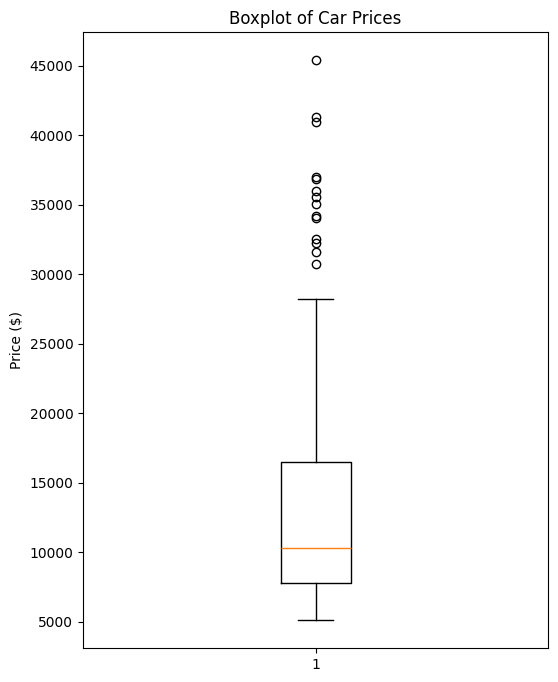

In [141]:
# 4. Extract clean prices and plot
clean_prices = auto["price"]

plt.figure(figsize=(6, 8))
plt.boxplot(clean_prices)  # Passed the variable, not a string
plt.title("Boxplot of Car Prices")
plt.ylabel("Price ($)")
plt.show()

## statistical summary

In [142]:
auto.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,197.000000,201.000000,199.000000,199.000000,201.000000,201.000000,201.000000
mean,0.840796,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,3.330711,3.256904,10.164279,103.396985,5117.587940,25.179104,30.686567,13207.129353
std,1.254802,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,0.270793,0.319256,4.004965,37.553843,480.521824,6.423220,6.815150,7947.066342
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


# b. Univariate Analysis

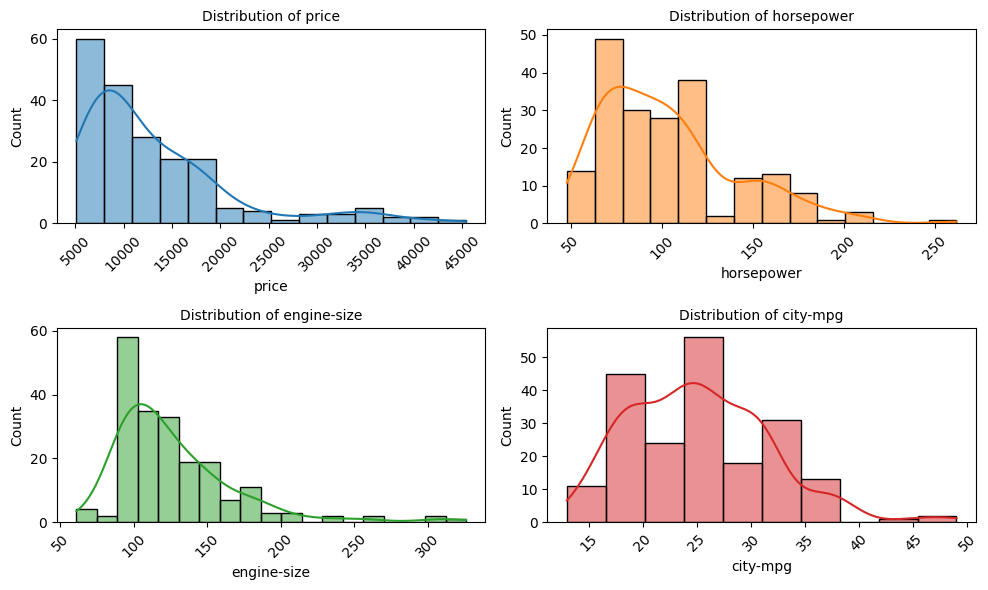

In [156]:
col_dict = {"price": 1, "horsepower": 2, "engine-size": 3, "city-mpg": 4}

# 1. Choose a distinct palette color for each subplot
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# 2. Reduced figure size for smaller charts
plt.figure(figsize=(10, 6))

for idx, (variable, i) in enumerate(col_dict.items()):
    plt.subplot(2, 2, i)
    # Passed unique color via the color parameter
    sns.histplot(auto[variable].dropna(), kde=True, color=colors[idx])
    plt.title(f"Distribution of {variable}", fontsize=10)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# c. Bivariate Analysis

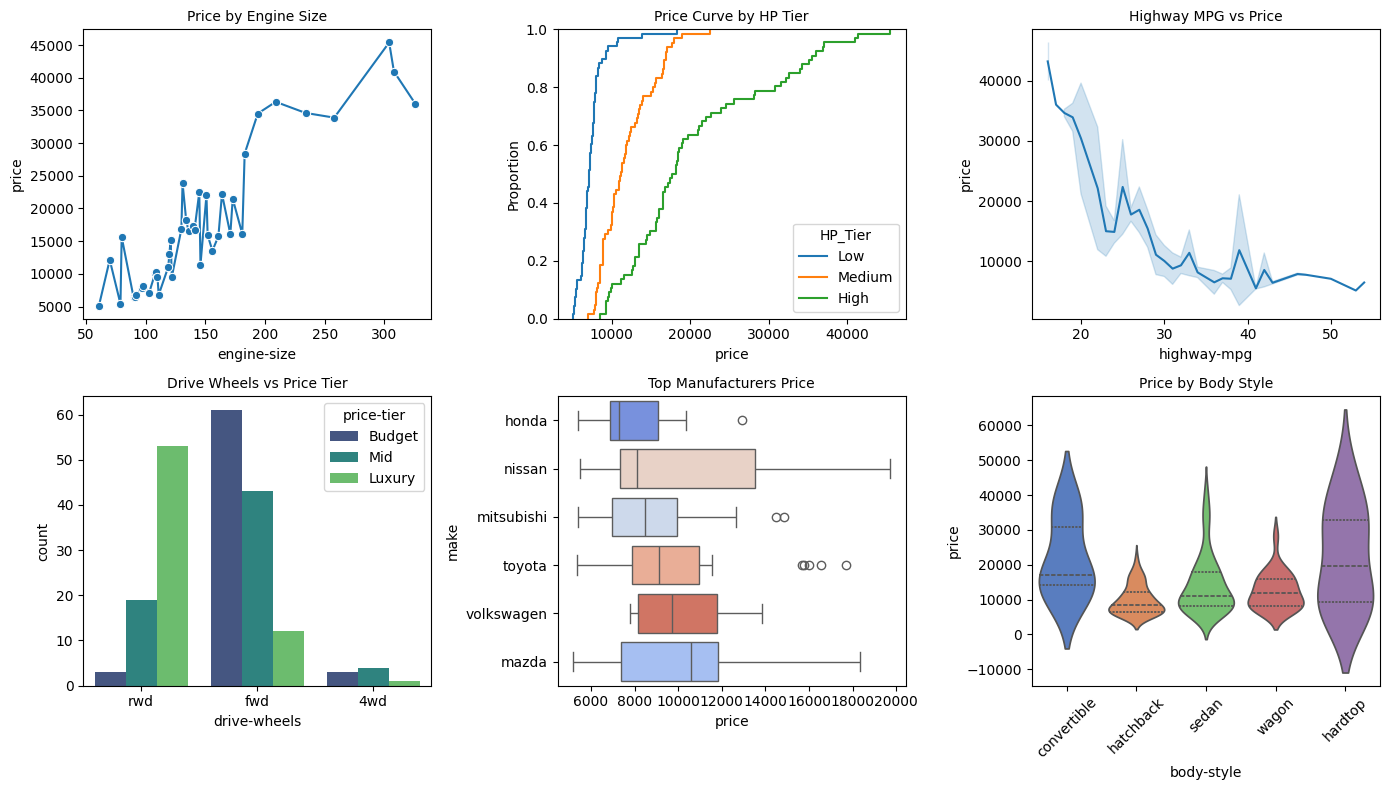

In [165]:
# Ensure target columns are numeric
num_cols = ["price", "horsepower", "engine-size", "highway-mpg"]
for col in num_cols:
    auto[col] = pd.to_numeric(auto[col], errors="coerce")

# Categorical cleaning list
cat_cols = ["drive-wheels", "make", "body-style"]
clean_auto = auto.dropna(subset=num_cols + cat_cols).copy()

# Create categorical tiers
clean_auto["HP_Tier"] = pd.qcut(
    clean_auto["horsepower"], q=3, labels=["Low", "Medium", "High"]
)
clean_auto["price-tier"] = pd.qcut(
    clean_auto["price"], q=3, labels=["Budget", "Mid", "Luxury"]
)

# 2x3 Grid Setup for compact, 3-column layout
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# Plot 1: Line Plot (Engine Size)
sns.lineplot(
    ax=axes[0],
    data=clean_auto,
    x="engine-size",
    y="price",
    marker="o",
    errorbar=None,
)
axes[0].set_title("Price by Engine Size", fontsize=10)

# Plot 2: ECDF (Horsepower Tiers)
sns.ecdfplot(ax=axes[1], data=clean_auto, x="price", hue="HP_Tier")
axes[1].set_title("Price Curve by HP Tier", fontsize=10)

# Plot 3: Line Plot (Highway MPG)
sns.lineplot(ax=axes[2], data=clean_auto, x="highway-mpg", y="price", errorbar="sd")
axes[2].set_title("Highway MPG vs Price", fontsize=10)

# Plot 4: Count Plot (Drive Wheels vs Price Tier)
sns.countplot(
    ax=axes[3], data=clean_auto, x="drive-wheels", hue="price-tier", palette="viridis"
)
axes[3].set_title("Drive Wheels vs Price Tier", fontsize=10)

# Plot 5: Boxplot for Car Make (Top Brands) -> Fixed Warning
top_makes = clean_auto["make"].value_counts().nlargest(6).index
filtered_makes = clean_auto[clean_auto["make"].isin(top_makes)]
sns.boxplot(
    ax=axes[4],
    data=filtered_makes,
    x="price",
    y="make",
    hue="make",
    legend=False,
    order=filtered_makes.groupby("make")["price"].median().sort_values().index,
    palette="coolwarm",
)
axes[4].set_title("Top Manufacturers Price", fontsize=10)

# Plot 6: Violinplot for Body Style -> Fixed Warning
sns.violinplot(
    ax=axes[5],
    data=clean_auto,
    x="body-style",
    y="price",
    hue="body-style",
    legend=False,
    palette="muted",
    inner="quart",
)
axes[5].set_title("Price by Body Style", fontsize=10)
axes[5].tick_params(axis="x", labelrotation=45)

plt.tight_layout()
plt.show()

# d. Multivariate Analysis

In [146]:
auto.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

In [147]:
# Get a list of all categorical column names
categorical_cols = auto.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical columns in the dataset:")
print(categorical_cols)

Categorical columns in the dataset:
['normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system']


In [145]:
# 1. Force all columns to numeric where possible (drops text/symbols to NaN)
numeric_df = auto.apply(pd.to_numeric, errors='coerce')

# 2. Get correlation of all features specifically with 'price'
price_corr = numeric_df.corr()['price'].drop('price')

# 3. Sort by absolute strength to find most relevant columns
top_correlated = price_corr.abs().sort_values(ascending=False)

# Display the top features and their actual correlation values
print("Columns most correlated to price:")
print(price_corr[top_correlated.index])

Columns most correlated to price:
engine-size          0.872335
curb-weight          0.834415
horsepower           0.810533
width                0.751265
highway-mpg         -0.704692
length               0.690628
city-mpg            -0.686571
wheel-base           0.584642
bore                 0.543436
normalized-losses    0.203254
height               0.135486
peak-rpm            -0.101649
symboling           -0.082391
stroke               0.082310
compression-ratio    0.071107
make                      NaN
fuel-type                 NaN
aspiration                NaN
num-of-doors              NaN
body-style                NaN
drive-wheels              NaN
engine-location           NaN
engine-type               NaN
num-of-cylinders          NaN
fuel-system               NaN
Name: price, dtype: float64


### columns with NAN are categorical columns

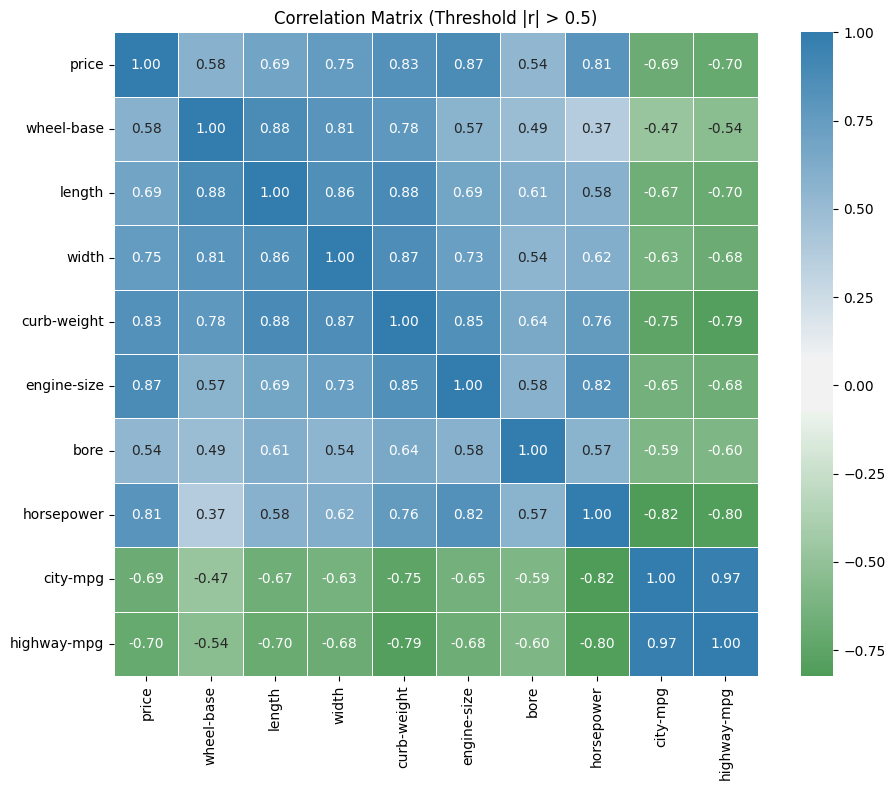

In [126]:
# 1. Dynamically select columns with absolute correlation above 0.5
strong_features = price_corr[price_corr.abs() > 0.5].index.tolist()
relevant_cols = ["price"] + strong_features

# 2. Compute the correlation matrix directly from your existing numeric_df
corr_matrix = numeric_df[relevant_cols].corr()

# Create a custom palette: Green (negative), Orange/Yellow (mid), Blue (positive)
custom_cmap = sns.diverging_palette(130, 240, s=85, l=50, sep=20, center="light", as_cmap=True)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=custom_cmap,
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix (Threshold |r| > 0.5)")
plt.tight_layout()
plt.savefig("correlation_matrix.png")
plt.show()

# Skewness

In [168]:
# 1. Select and clean numeric features
features = ["price", "engine-size", "horsepower", "highway-mpg", "curb-weight", "width"]
for col in features:
    auto[col] = pd.to_numeric(auto[col], errors="coerce")

# Drop missing values for calculations
df_clean = auto[features].dropna().copy()

# --- SKEWNESS ---
print("--- Feature Skewness ---")
print(df_clean.skew())
print("\n*Note: Highly skewed features (> |1|) may need log transformation.*")



--- Feature Skewness ---
price          1.793654
engine-size    1.973596
horsepower     1.141584
highway-mpg    0.548218
curb-weight    0.700441
width          0.881262
dtype: float64

*Note: Highly skewed features (> |1|) may need log transformation.*


## Skewness Analysis Conclusion:
1. Skewness measures the asymmetry of a feature's probability distribution around its mean.
2. Skewness values greater than $1$ or less than $-1$ indicate high skewness, which can violate the assumptions of linear models and degrade prediction performance.
3. In this dataset:price, engine-size, and horsepower are highly right-skewed ($>1.0$).highway-mpg, curb-weight, and width are moderately symmetric ($<1.0$).
4. To fix this, the highly skewed features will require transformation techniques—such as logarithmic (np.log1p), square root, or Box-Cox transformations—to make their distributions more symmetrical and improve model accuracy before training.





# VIF

In [ ]:
# --- VIF (Multicollinearity)
print("\n--- Variance Inflation Factor (VIF) ---")
# Add constant intercept for VIF calculation
X = df_clean.copy()
X['intercept'] = 1

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns[:-1] # Exclude intercept row from output display
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns) - 1)]
print(vif_data)
print("\n*Note: VIF > 5 indicates high multicollinearity.*")




--- Variance Inflation Factor (VIF) ---
       Feature       VIF
0  engine-size  5.590920
1   horsepower  5.040715
2  highway-mpg  4.178531
3  curb-weight  8.585370
4        width  4.122090

*Note: VIF > 5 indicates high multicollinearity.*


## VIF
1. A high VIF suggest that the predictor variable may be highly correlated with other predictor variables in the model.
2. Conclusion: Features with VIF values above 10 are typically considered to have problematic levels of multicollinearity. In this case we have none.

# Normalization

In [169]:
from sklearn.preprocessing import MinMaxScaler

# 1. Target variable
target_col = "price"

# 2. Separate relevant numeric features from categorical text features
numeric_features = ["engine-size", "horsepower", "highway-mpg", "curb-weight", "width"]

# 3. Clean and convert to numeric types
for col in numeric_features + [target_col]:
    auto[col] = pd.to_numeric(auto[col], errors="coerce")

# 4. Drop missing rows across selected variables to avoid scaling errors
clean_auto = auto.dropna(subset=numeric_features + [target_col]).copy()

# 5. Separate features (X) and target label (y)
X = clean_auto[numeric_features]
y = clean_auto[target_col]

# 6. Initialize and apply the MinMaxScaler
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# 7. Convert back to a DataFrame for clean visualization
X_normalized_df = pd.DataFrame(X_normalized, columns=numeric_features, index=clean_auto.index)

# Print results
print("--- First 5 Rows of Normalized Features (Scaled 0 to 1) ---")
print(X_normalized_df.head())

--- First 5 Rows of Normalized Features (Scaled 0 to 1) ---
   engine-size  horsepower  highway-mpg  curb-weight     width
0     0.260377    0.294393     0.289474     0.411171  0.324786
1     0.260377    0.294393     0.289474     0.411171  0.324786
2     0.343396    0.495327     0.263158     0.517843  0.444444
3     0.181132    0.252336     0.368421     0.329325  0.504274
4     0.283019    0.313084     0.157895     0.518231  0.521368


## Feature selection
• What features seem most related to price?

In [170]:
# Drop columns with no predictive value or low correlation to price
columns_to_drop = ["car_ID", "normalized-losses", "peak-rpm", "stroke", "symboling"]

# Drop only if they exist in the dataframe to avoid errors
auto.drop(columns=[col for col in columns_to_drop if col in auto.columns], inplace=True)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

## Feature Scaling

# HYPOTHESIS TESTING
1. Does higher horsepower always mean higher price?


# Linear Regression

# Random Forest